#### Imports and Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

#### MySQL Connection

In [3]:
# ── Connect to MySQL ──────────────────────────────────────────
DB_USER     = "root"
DB_PASSWORD = "root123"
DB_HOST     = "localhost"
DB_PORT     = 3306
DB_NAME     = "fintech_risk"

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True
)

#### Load tables

In [4]:
# ── Load all three source tables ──────────────────────────────
loans        = pd.read_sql("SELECT * FROM loans",        engine, parse_dates=["disbursal_date"])
repayments   = pd.read_sql("SELECT * FROM repayments",   engine, parse_dates=["due_date","paid_date"])
transactions = pd.read_sql("SELECT * FROM transactions", engine, parse_dates=["txn_date"])

In [5]:
# Default flag: any loan with at least one DPD90+ row
defaulted_loans = (
    repayments[repayments["dpd"] >= 90]["loan_id"]
    .unique()
)
loans["is_defaulted"] = loans["loan_id"].isin(defaulted_loans).astype(int)

In [6]:
# Load the combined signals data from the previous step
signals_combined = pd.read_csv("../data/processed/signals_combined.csv")

#### Step A: Latest repayment state per loan
We want the most recent DPD and whether the loan had a partial payment in the last 2 months — both are point-in-time risk indicators, not historical aggregates.

In [7]:
rep_sorted = repayments.sort_values(["loan_id","due_date"])

In [8]:
# Most recent DPD per loan
latest_dpd = (
    rep_sorted
    .groupby("loan_id")
    .last()[["dpd","paid_amount","emi_amount"]]
    .rename(columns={"dpd":"latest_dpd"})
    .reset_index()
)

In [9]:
# Partial payment flag: did either of the last 2 EMIs have paid_amount < 95% of emi_amount?
last_2_emis = (
    rep_sorted
    .groupby("loan_id")
    .tail(2)
)
last_2_emis

,repayment_id,loan_id,due_date,paid_date,emi_amount,paid_amount,dpd,payment_mode
22,RP000000023,LN00000001,2026-01-18,2026-01-18,112327.33,109996.11,0,netbanking
23,RP000000024,LN00000001,2026-02-17,2026-02-24,112327.33,117195.92,7,NACH
46,RP000000047,LN00000002,2026-12-30,2026-12-30,185733.80,184414.30,0,UPI
47,RP000000048,LN00000002,2027-01-29,2027-01-29,185733.80,182990.20,0,UPI
70,RP000000071,LN00000003,2026-08-14,2026-08-14,88207.37,86455.14,0,cheque
...,...,...,...,...,...,...,...,...
959951,RP000959952,LN00039998,2027-06-14,2027-06-14,27923.38,28143.16,0,NACH
959974,RP000959975,LN00039999,2026-04-04,2026-04-04,18623.98,18543.55,0,UPI
959975,RP000959976,LN00039999,2026-05-04,2026-05-04,18623.98,18423.99,0,UPI
959998,RP000959999,LN00040000,2025-12-03,2025-12-03,6003.14,6097.87,0,netbanking


In [10]:
partial_flag = (
    last_2_emis
    .assign(is_partial=lambda df: df.paid_amount < df.emi_amount * 0.95)
    .groupby("loan_id")["is_partial"]
    .max()         # 1 if EITHER of last 2 EMIs was partial
    .rename("had_recent_partial")
    .reset_index()
)

#### Step B: Combine everything into master table


In [12]:
master = (
    loans[["loan_id", "customer_id", "loan_amount", "tenure_months",
           "credit_score_band", "income_band", "city", "acquisition_channel"
          ]]
    .merge(latest_dpd[["loan_id", "latest_dpd"]], on="loan_id", how="left")
    .merge(partial_flag, on="loan_id", how="left")
    .merge(signals_combined[["loan_id", "signals_firing", "decline_spike_flag", 
                             "upi_shift_flag", "amount_drop_flag", "diversity_drop_flag"]]
          , on="loan_id", how="left")
)

In [13]:
# Fill NaN for loans with no transaction coverage
master["signals_firing"]    = master["signals_firing"].fillna(0)
master["had_recent_partial"]= master["had_recent_partial"].fillna(0)

In [14]:
# City tier flag
tier1 = ["Mumbai","Delhi","Bengaluru","Hyderabad","Chennai","Kolkata","Pune"]
master["city_tier"] = np.where(master["city"].isin(tier1), "tier1", "tier2")

In [15]:
master.head()

,loan_id,customer_id,loan_amount,tenure_months,credit_score_band,income_band,city,acquisition_channel,latest_dpd,had_recent_partial,signals_firing,decline_spike_flag,upi_shift_flag,amount_drop_flag,diversity_drop_flag,city_tier
0,LN00000001,CUST0013536,1862622.24,18,650-850,>15L,Delhi,referral,7,False,3.0,1.0,1.0,1.0,0.0,tier1
1,LN00000002,CUST0028028,2018131.97,12,600-650,>15L,Pune,DSA,0,False,0.0,NaN,NaN,NaN,NaN,tier1
2,LN00000003,CUST0019977,1422386.90,18,650-850,10-15L,Kolkata,organic,0,False,1.0,1.0,0.0,0.0,0.0,tier1
3,LN00000004,CUST0017979,448660.49,24,550-600,6-10L,Mumbai,organic,90,False,1.0,1.0,0.0,0.0,0.0,tier1
4,LN00000005,CUST0028977,112484.70,24,650-850,3-6L,Pune,organic,0,False,0.0,NaN,NaN,NaN,NaN,tier1


In [16]:
print(f"Master table shape: {master.shape}")
print(master.dtypes)

Master table shape: (40000, 16)
loan_id                 object
customer_id             object
loan_amount            float64
tenure_months            int64
credit_score_band       object
income_band             object
city                    object
acquisition_channel     object
latest_dpd               int64
had_recent_partial        bool
signals_firing         float64
decline_spike_flag     float64
upi_shift_flag         float64
amount_drop_flag       float64
diversity_drop_flag    float64
city_tier               object
dtype: object


#### Risk score computation
Each factor adds points. Explicit, auditable, defensible.
Every threshold is a deliberate business decision — not a learned parameter.

In [17]:
def compute_risk_score(row):
    score = 0
    reasons = []

    # Layer 1: Credit band 
    # Source: loans.credit_score_band
    # 600-650 gets +3 because its NPA rate is 2.8x portfolio avg
    # That's not an assumption — we validated it in Step 1 EDA
    if row["credit_score_band"] == "600-650":
        score += 3; reasons.append("band_600_650(+3)")
    elif row["credit_score_band"] == "300-550":
        score += 2; reasons.append("band_300_550(+2)")
    elif row["credit_score_band"] == "550-600":
        score += 1; reasons.append("band_550_600(+1)")
    # 650-850 adds 0

    # Layer 2: Income band
    # Source: loans.income_band
    # Lower income = lower repayment capacity buffer
    if row["income_band"] == "<3L":
        score += 2; reasons.append("income_lt3L(+2)")
    elif row["income_band"] == "3-6L":
        score += 1; reasons.append("income_3_6L(+1)")
    # 6L+ adds 0

    # Layer 3: City tier
    # Source: derived from loans.city
    # Tier-2 cities have 1.6x higher decline rates (validated in EDA)
    if row["city_tier"] == "tier2":
        score += 1; reasons.append("tier2_city(+1)")

    # Layer 4: Tenure 
    # Source: loans.tenure_months
    # Longer tenure = longer exposure window = more lifecycle risk
    # A 36-month loan has 3x the MOB to accumulate a default event
    if row["tenure_months"] > 24:
        score += 1; reasons.append("long_tenure(+1)")

    # Layer 5: Behavioral signals 
    # Source: signals_combined from Step 4
    # 3+ signals co-firing = 87% precision in pre-default window
    # This is the most powerful single input in the score
    sf = row["signals_firing"]
    if sf >= 3:
        score += 3; reasons.append(f"signals_{int(sf)}_firing(+3)")
    elif sf >= 1:
        score += 1; reasons.append(f"signals_{int(sf)}_firing(+1)")

    # Layer 6: Repayment behavior 
    # Source: repayments table aggregated in Sub-step 5.1

    # Partial payment in last 2 EMIs — earliest detectable
    # distress signal from the repayments table
    if row["had_recent_partial"] == 1:
        score += 2; reasons.append("recent_partial_pay(+2)")

    # Already showing lateness but not yet DPD30
    # This is the customer right on the edge — one more missed
    # payment tips them into the DPD30 bucket
    if 1 <= row["latest_dpd"] <= 29:
        score += 2; reasons.append("dpd_1_29(+2)")

    return pd.Series({
        "risk_score":  score,
        "score_reason": " | ".join(reasons) if reasons else "no_risk_factors"
    })

In [18]:
# Apply row-wise — function returns a Series so expand=True
score_cols = master.apply(compute_risk_score, axis=1)

In [20]:
score_cols.head()

,risk_score,score_reason
0,5,signals_3_firing(+3) | dpd_1_29(+2)
1,3,band_600_650(+3)
2,1,signals_1_firing(+1)
3,2,band_550_600(+1) | signals_1_firing(+1)
4,1,income_3_6L(+1)


In [21]:
master = pd.concat([master, score_cols], axis=1)

In [22]:
master.head()

,loan_id,customer_id,loan_amount,tenure_months,credit_score_band,income_band,city,acquisition_channel,latest_dpd,had_recent_partial,signals_firing,decline_spike_flag,upi_shift_flag,amount_drop_flag,diversity_drop_flag,city_tier,risk_score,score_reason
0,LN00000001,CUST0013536,1862622.24,18,650-850,>15L,Delhi,referral,7,False,3.0,1.0,1.0,1.0,0.0,tier1,5,signals_3_firing(+3) | dpd_1_29(+2)
1,LN00000002,CUST0028028,2018131.97,12,600-650,>15L,Pune,DSA,0,False,0.0,NaN,NaN,NaN,NaN,tier1,3,band_600_650(+3)
2,LN00000003,CUST0019977,1422386.90,18,650-850,10-15L,Kolkata,organic,0,False,1.0,1.0,0.0,0.0,0.0,tier1,1,signals_1_firing(+1)
3,LN00000004,CUST0017979,448660.49,24,550-600,6-10L,Mumbai,organic,90,False,1.0,1.0,0.0,0.0,0.0,tier1,2,band_550_600(+1) | signals_1_firing(+1)
4,LN00000005,CUST0028977,112484.70,24,650-850,3-6L,Pune,organic,0,False,0.0,NaN,NaN,NaN,NaN,tier1,1,income_3_6L(+1)


In [23]:
print(f"\nScore distribution:")
print(master["risk_score"].describe().round(2))
print(f"\nScore value counts:")
print(master["risk_score"].value_counts().sort_index())


Score distribution:
count    40000.00
mean         3.54
std          2.20
min          0.00
25%          2.00
50%          3.00
75%          5.00
max         12.00
Name: risk_score, dtype: float64

Score value counts:
risk_score
0     2255
1     5569
2     6654
3     6902
4     6076
5     4673
6     3721
7     2227
8     1114
9      540
10     181
11      75
12      13
Name: count, dtype: int64


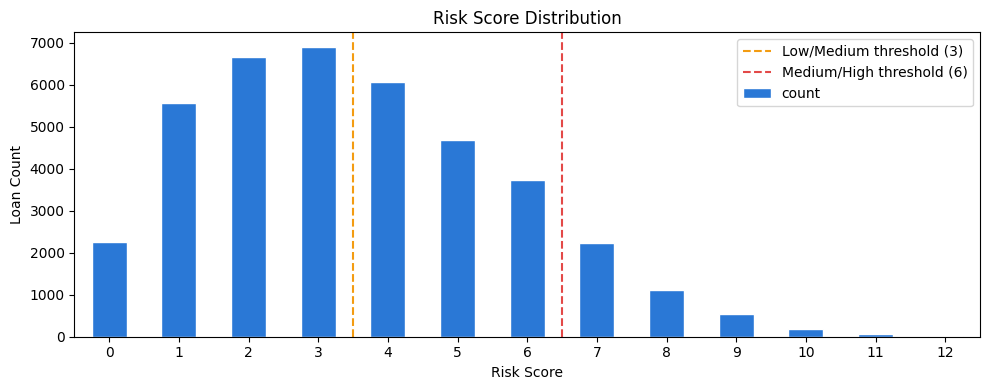

In [32]:
plt.figure(figsize=(10,4))
master["risk_score"].value_counts().sort_index().plot(
    kind="bar", color="#2a78d6", edgecolor="white"
)
plt.axvline(x=3.5, color="#f39c12", linestyle="--", linewidth=1.5, label="Low/Medium threshold (3)")
plt.axvline(x=6.5, color="#e34948", linestyle="--", linewidth=1.5, label="Medium/High threshold (6)")
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Loan Count")
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../eda_outputs/risk_score_dist.png", dpi=150)
plt.show()

#### Map score to Low / Medium / High tier 
##### Thresholds:
#####   0–3   →  Low     (no intervention)
#####   4–6   →  Medium  (soft intervention)
#####   7+    →  High    (hard intervention, collections escalation)

In [24]:
def assign_tier(score):
    if score <= 3:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

In [25]:
master["risk_tier"] = master["risk_score"].apply(assign_tier)
print("\nRisk tier distribution:")
print(master["risk_tier"].value_counts())
print(f"\nAs percentage of portfolio:")
print(master["risk_tier"].value_counts(normalize=True).mul(100).round(1))


Risk tier distribution:
risk_tier
Low       21380
Medium    14470
High       4150
Name: count, dtype: int64

As percentage of portfolio:
risk_tier
Low       53.4
Medium    36.2
High      10.4
Name: proportion, dtype: float64


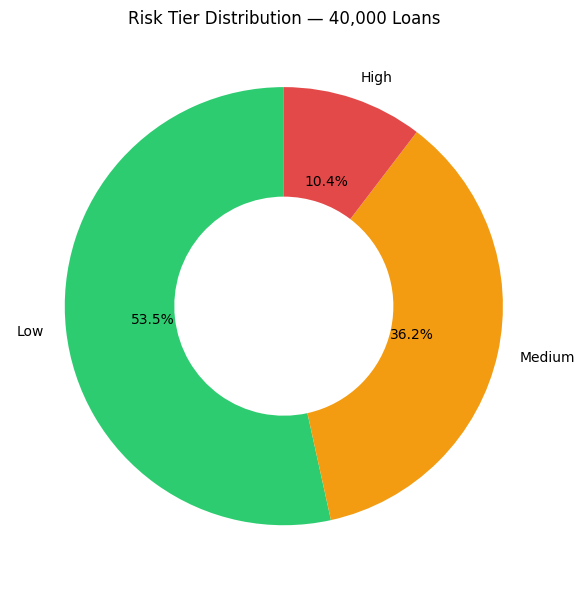

In [33]:
tier_counts = master["risk_tier"].value_counts()
colors = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e34948"}
plt.figure(figsize=(6,6))
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
        colors=[colors[t] for t in tier_counts.index],
        startangle=90, wedgeprops=dict(width=0.5))
plt.title("Risk Tier Distribution — 40,000 Loans")
plt.tight_layout()
plt.savefig("../eda_outputs/risk_tier_dist.png", dpi=150)
plt.show()

#### Validation
##### The risk tiers are only useful if High-tier loans actually default at a higher rate than Low-tier loans. 
##### This is the one check that separates a defensible scoring system from a made-up one.

In [27]:
# Merge risk tier back to ground truth default flag
validation = master.merge(
    loans[["loan_id", "is_defaulted"]],
    on='loan_id', how='left'
)

In [28]:
validation.head()

,loan_id,customer_id,loan_amount,tenure_months,credit_score_band,income_band,city,acquisition_channel,latest_dpd,had_recent_partial,signals_firing,decline_spike_flag,upi_shift_flag,amount_drop_flag,diversity_drop_flag,city_tier,risk_score,score_reason,risk_tier,is_defaulted
0,LN00000001,CUST0013536,1862622.24,18,650-850,>15L,Delhi,referral,7,False,3.0,1.0,1.0,1.0,0.0,tier1,5,signals_3_firing(+3) | dpd_1_29(+2),Medium,0
1,LN00000002,CUST0028028,2018131.97,12,600-650,>15L,Pune,DSA,0,False,0.0,NaN,NaN,NaN,NaN,tier1,3,band_600_650(+3),Low,0
2,LN00000003,CUST0019977,1422386.90,18,650-850,10-15L,Kolkata,organic,0,False,1.0,1.0,0.0,0.0,0.0,tier1,1,signals_1_firing(+1),Low,0
3,LN00000004,CUST0017979,448660.49,24,550-600,6-10L,Mumbai,organic,90,False,1.0,1.0,0.0,0.0,0.0,tier1,2,band_550_600(+1) | signals_1_firing(+1),Low,1
4,LN00000005,CUST0028977,112484.70,24,650-850,3-6L,Pune,organic,0,False,0.0,NaN,NaN,NaN,NaN,tier1,1,income_3_6L(+1),Low,0


In [29]:
# Default rate by risk tier — the key validation metric
default_by_tier = (
    validation
    .groupby("risk_tier")["is_defaulted"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean":"default_rate", "sum":"defaults", "count":"total"})
    .round(4)
)
default_by_tier["default_rate_pct"] = (
    default_by_tier["default_rate"] * 100
).round(2)

In [30]:
print("\n── Validation: Default rate by risk tier ──")
print(default_by_tier[["total","defaults","default_rate_pct"]])


── Validation: Default rate by risk tier ──
           total  defaults  default_rate_pct
risk_tier                                   
High        4150      3017             72.70
Low        21380      5942             27.79
Medium     14470      6304             43.57


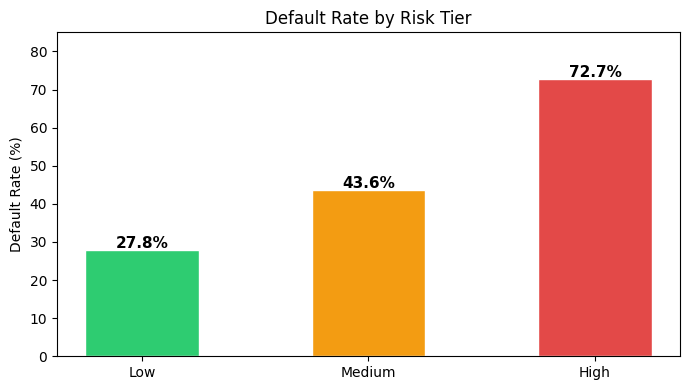

In [34]:
tier_order = ["Low", "Medium", "High"]
rates = [default_by_tier.loc[t, "default_rate_pct"] for t in tier_order]
colors = ["#2ecc71", "#f39c12", "#e34948"]

plt.figure(figsize=(7,4))
bars = plt.bar(tier_order, rates, color=colors, edgecolor="white", width=0.5)
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{rate:.1f}%", ha="center", fontsize=11, fontweight="bold")
plt.title("Default Rate by Risk Tier")
plt.ylabel("Default Rate (%)")
plt.ylim(0, 85)
plt.tight_layout()
plt.savefig("../eda_outputs/default_by_tier.png", dpi=150)
plt.show()

In [35]:
# Score distribution by credit band — sanity check
print("\n── Mean risk score by credit band ──")
print(master.groupby("credit_score_band")["risk_score"].mean().round(2))


── Mean risk score by credit band ──
credit_score_band
300-550    4.06
550-600    3.02
600-650    5.65
650-850    1.96
Name: risk_score, dtype: float64


In [36]:
# Tier distribution by city tier
print("\n── Risk tier by city tier ──")
print(
    master.groupby(["city_tier","risk_tier"])
    .size()
    .unstack(fill_value=0)
)


── Risk tier by city tier ──
risk_tier  High    Low  Medium
city_tier                     
tier1      1444  13315    6767
tier2      2706   8065    7703


In [37]:
# Signal contribution: what % of High-risk accounts
# were flagged by behavioral signals vs credit features alone?
high_risk = master[master["risk_tier"] == "High"]
print(f"\n── High-risk accounts: signal breakdown ──")
print(f"With 3+ behavioral signals: "
      f"{(high_risk['signals_firing'] >= 3).mean():.1%}")
print(f"With partial payment flag:  "
      f"{(high_risk['had_recent_partial'] == 1).mean():.1%}")
print(f"With DPD 1-29:             "
      f"{((high_risk['latest_dpd'] >= 1) & (high_risk['latest_dpd'] <= 29)).mean():.1%}")


── High-risk accounts: signal breakdown ──
With 3+ behavioral signals: 36.9%
With partial payment flag:  61.5%
With DPD 1-29:             28.6%


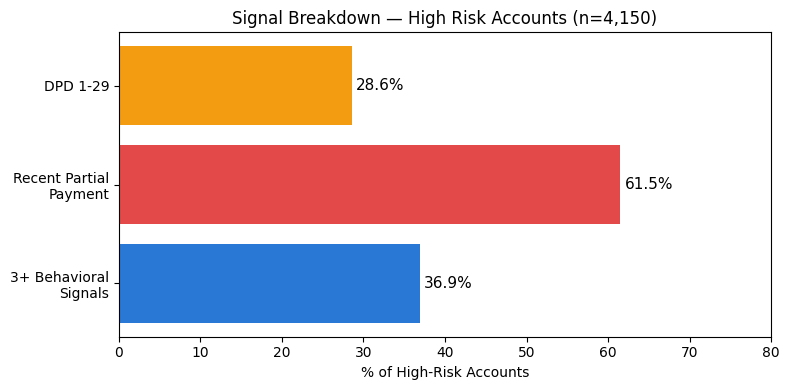

In [38]:
labels = ["3+ Behavioral\nSignals", "Recent Partial\nPayment", "DPD 1-29"]
values = [36.9, 61.5, 28.6]
colors = ["#2a78d6", "#e34948", "#f39c12"]

plt.figure(figsize=(8,4))
bars = plt.barh(labels, values, color=colors)
for bar, val in zip(bars, values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val}%", va="center", fontsize=11)
plt.title("Signal Breakdown — High Risk Accounts (n=4,150)")
plt.xlabel("% of High-Risk Accounts")
plt.xlim(0, 80)
plt.tight_layout()
plt.savefig("../eda_outputs/high_risk_signals.png", dpi=150)
plt.show()

In [39]:
# Preparing data for export 
risk_export=master[["loan_id","customer_id","credit_score_band","income_band","city","city_tier",
    "loan_amount","tenure_months","latest_dpd","had_recent_partial","signals_firing",
    "decline_spike_flag","upi_shift_flag","amount_drop_flag","diversity_drop_flag",
    "risk_score","score_reason","risk_tier"]].copy()
risk_export["risk_tier"]=risk_export["risk_tier"].astype(str)

In [40]:
risk_export.head()

,loan_id,customer_id,credit_score_band,income_band,city,city_tier,loan_amount,tenure_months,latest_dpd,had_recent_partial,signals_firing,decline_spike_flag,upi_shift_flag,amount_drop_flag,diversity_drop_flag,risk_score,score_reason,risk_tier
0,LN00000001,CUST0013536,650-850,>15L,Delhi,tier1,1862622.24,18,7,False,3.0,1.0,1.0,1.0,0.0,5,signals_3_firing(+3) | dpd_1_29(+2),Medium
1,LN00000002,CUST0028028,600-650,>15L,Pune,tier1,2018131.97,12,0,False,0.0,NaN,NaN,NaN,NaN,3,band_600_650(+3),Low
2,LN00000003,CUST0019977,650-850,10-15L,Kolkata,tier1,1422386.90,18,0,False,1.0,1.0,0.0,0.0,0.0,1,signals_1_firing(+1),Low
3,LN00000004,CUST0017979,550-600,6-10L,Mumbai,tier1,448660.49,24,90,False,1.0,1.0,0.0,0.0,0.0,2,band_550_600(+1) | signals_1_firing(+1),Low
4,LN00000005,CUST0028977,650-850,3-6L,Pune,tier1,112484.70,24,0,False,0.0,NaN,NaN,NaN,NaN,1,income_3_6L(+1),Low


In [41]:
# Write to MySQL & CSV
risk_export.to_sql("risk_scored_loans",engine,if_exists="replace",index=False,
                   chunksize=5000,method="multi")
print("risk_scored_loans written to MySQL")
risk_export.to_csv("../data/processed/risk_scored_loans.csv",index=False)

risk_scored_loans written to MySQL


#### Findings

    1. Tier separation (headline):
        High-risk tier (score 7+) defaults at 72.70% vs Low-risk at 27.79% — a 2.62x separation.
        With only 10.4% of the portfolio flagged High-risk, the scoring system concentrates risk identification without over-flagging.

    2. Partial payment is the dominant signal:
        61.5% of High-risk accounts carried a recent partial payment flag — the single strongest contributor among all behavioral signals. 
        More predictive than transaction decline (36.9% with 3+ signals) or early DPD (28.6% with DPD1-29).

    3. Tier-2 geographic concentration: 
        Tier-2 cities account for 65.2% of High-risk accounts (2,706 of 4,150) despite being a smaller share of total loans.
        Collection resources should be disproportionately allocated to Tier-2.

    4. Score distribution is healthy:
        Mean score 3.54, median 3.0, max 12. No ceiling concentration — the scoring range is being used effectively. 
        53.4% Low / 36.2% Medium / 10.4% High is a realistic operational split for a BNPL portfolio.

    5. 600-650 band scores highest (5.65 mean):
        Confirms EDA finding — this band is the primary driver of High-risk concentration and should be subject to tighter underwriting limits or lower credit exposure caps.